# 01 — Sleep-EDF Exploration

This notebook performs an initial exploration of prepared Sleep-EDF hypnogram data.

## Objectives

- load the prepared hypnogram dataset;
- inspect dataset structure and missing values;
- summarize sleep-stage durations;
- visualize sleep-stage distribution;
- prepare observations for feature engineering.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the project root by looking for README.md and data/."""
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Project root not found. Make sure README.md and data/ exist."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "notebooks" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## Load prepared hypnogram data

The notebook uses `data/processed/hypno_df.csv`, which contains sleep-stage annotations and their durations.

In [3]:
hypno_path = PROCESSED_DIR / "hypno_df.csv"

if not hypno_path.exists():
    raise FileNotFoundError(
        "Expected file not found: data/processed/hypno_df.csv. "
        "Run the dataset-building notebook first or place the file in data/processed/."
    )

hypno_df = pd.read_csv(hypno_path)

display(hypno_df.head())


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0


In [4]:
dataset_overview = pd.DataFrame({
    "metric": ["rows", "columns"],
    "value": [hypno_df.shape[0], hypno_df.shape[1]],
})

display(dataset_overview)
display(pd.DataFrame({"column": hypno_df.columns, "dtype": hypno_df.dtypes.astype(str).values}))


,metric,value
0,rows,153
1,columns,2


,column,dtype
0,description,str
1,duration,float64


## Missing values

Before feature engineering, the dataset is checked for missing values.

In [5]:
missing_values = (
    hypno_df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)

display(missing_values)


,column,missing_values
0,description,0
1,duration,0


## Sleep-stage duration summary

Sleep-stage duration is aggregated by annotation label. This provides a compact overview of how the recording is distributed across stages.

In [6]:
required_columns = {"description", "duration"}
missing_required = required_columns - set(hypno_df.columns)

if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

stage_summary = (
    hypno_df
    .groupby("description", as_index=False)
    .agg(
        episodes=("duration", "count"),
        total_duration_seconds=("duration", "sum"),
        mean_duration_seconds=("duration", "mean"),
    )
)

stage_summary["total_duration_minutes"] = stage_summary["total_duration_seconds"] / 60
stage_summary = stage_summary.sort_values("total_duration_seconds", ascending=False)

display(stage_summary)


,description,episodes,total_duration_seconds,mean_duration_seconds,total_duration_minutes
5,Sleep stage W,12,59910.0,4992.500000,998.5
1,Sleep stage 2,40,7500.0,187.500000,125.0
4,Sleep stage R,6,3750.0,625.000000,62.5
3,Sleep stage 4,23,3570.0,155.217391,59.5
2,Sleep stage 3,48,3030.0,63.125000,50.5
0,Sleep stage 1,24,1740.0,72.500000,29.0


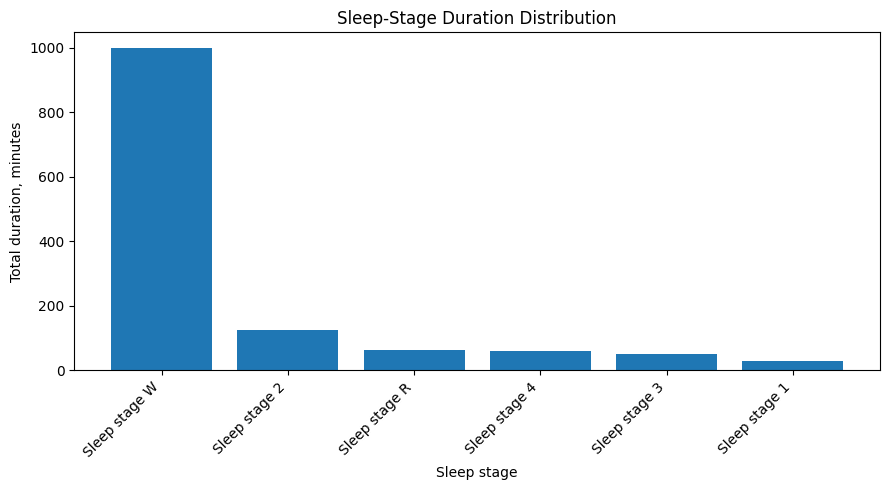

In [7]:
plt.figure(figsize=(9, 5))
plt.bar(stage_summary["description"], stage_summary["total_duration_minutes"])
plt.xlabel("Sleep stage")
plt.ylabel("Total duration, minutes")
plt.title("Sleep-Stage Duration Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = IMAGES_DIR / "01_sleep_stage_duration_distribution.png"
plt.savefig(plot_path, dpi=150)

plt.show()


## Episode duration distribution

The distribution of episode durations helps identify long wake periods, short sleep-stage fragments, and possible annotation imbalance.

,duration_seconds
count,153.000000
mean,519.607843
std,3295.552003
min,30.000000
25%,30.000000
50%,60.000000
75%,150.000000
max,30630.000000


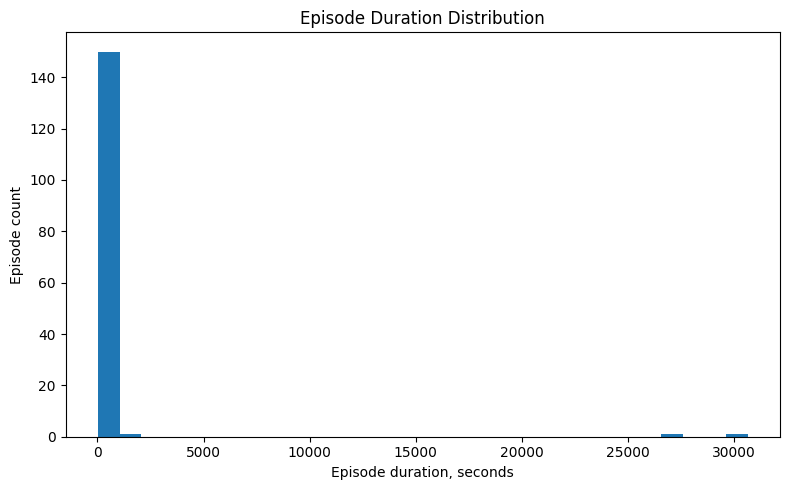

In [8]:
duration_summary = hypno_df["duration"].describe().to_frame(name="duration_seconds")
display(duration_summary)

plt.figure(figsize=(8, 5))
plt.hist(hypno_df["duration"], bins=30)
plt.xlabel("Episode duration, seconds")
plt.ylabel("Episode count")
plt.title("Episode Duration Distribution")
plt.tight_layout()

plot_path = IMAGES_DIR / "01_episode_duration_distribution.png"
plt.savefig(plot_path, dpi=150)

plt.show()


## Summary

The prepared Sleep-EDF hypnogram dataset contains sleep-stage annotations and episode durations. The initial exploration shows the distribution of sleep stages and highlights the importance of feature engineering before downstream sleep and cognition analysis.

The next notebooks use these annotations to build structured sleep features.